## Proyecto EDA con Python
Tenemos dos ficheros, un xlsx y un csv, cargaremos los dos e iremos desgranando el contenido de cada uno

In [360]:
#Importamos todas la librerias que vamos a utilizar en este proyecto
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Dejamos estas comentadas porque de momento no se van a utilizar
#import squarify
#import statsmodels.api as sm

#Aplicamos este método para que nos muestre todas las columnas de los dataframe
pd.set_option('display.max_columns', None)

In [361]:
# Cargamos el fichero de clientes que contiene 3 hojas, una por cada año
df_2012 = pd.read_excel("customer-details.xlsx", sheet_name='2012', index_col = "ID") # Cargamos cada una de las hojas del fichero Excel
df_2012["año"] = "2012" # Añadimos en cada tabla una columna con el año de origen
df_2013 = pd.read_excel("customer-details.xlsx", sheet_name='2013', index_col = "ID") # Definimos la columnas "ID" como índice
df_2013["año"] = "2013"
df_2014 = pd.read_excel("customer-details.xlsx", sheet_name='2014', index_col = "ID") # La columna A sobra, podríamos usar -> usecols = "B:G"
df_2014["año"] = "2014"

tablas = [df_2012, df_2013,df_2014] # Creamos esta variable para almacenar las tablas por si a futuro hay que añadir más años

df_customer = pd.concat(tablas) # Unimos todas las tablas en un solo DataFrame

df_customer.sample(5) # Visualizamos el resultado

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,año
ID,,,,,,,
cc772ad9-5fe1-4651-a8d9-abb4e4cc184f,2177,152293,2,0,2013-11-18,22,2013
0e96316d-9825-4217-afc2-b479ad9fa8e2,4069,114631,0,0,2014-02-11,2,2014
77fac03b-4334-4860-ab6c-30379360ea01,3900,169268,2,0,2014-11-22,20,2014
1d38303e-738c-4d28-a66b-091494c9ebc8,1785,79283,0,0,2013-10-04,8,2013
53950289-192e-40ee-8551-e53cc2175fb7,13853,49428,0,0,2014-12-03,30,2014


In [362]:
df_clientes = df_customer.drop(columns=["Unnamed: 0"]) #Eliminamos ahora esta columna "A" sobrante y cambiamos el nombre del dataframe

In [363]:
#Hacemos una exploración del volumen de datos que vamos manejar
print(f"Nuestro dataframe original consta de {df_clientes.shape[0]} filas y {df_clientes.shape[1]} columnas")
print(f"El volumen de datos que contiene nuestro dataframe es: {df_clientes.size}")

Nuestro dataframe original consta de 43170 filas y 6 columnas
El volumen de datos que contiene nuestro dataframe es: 259020


In [364]:
#Veamos si las 43.170 filas corresponden a ID's únicos o si son repetidos
df_clientes.index.nunique()

43170

A la vista de estos datos, ya que TODOS los registros son únicos, deducimos que la clasificación por años corresponde a la fecha en la que ese ID se convirtió en cliente de la empresa

🔽  Cargamos ahora el fichero "bank-additional.csv" 🔽

In [365]:
df_bank = pd.read_csv("bank-additional.csv", index_col = "id_") # Cargamos el primer fichero y definimos la columna que hará de índice

In [366]:
#Hacemos una visualización general de nuestros datos
df_bank.sample(5)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude
id_,,,,,,,,,,,,,,,,,,,,,,,
a6ca58b5-918b-427c-8a2e-b919d16c3b6e,19937,34.0,admin.,MARRIED,university.degree,0.0,0.0,0.0,cellular,147,1,999,0,NONEXISTENT,1.4,"93,444","-36,1","4,966","5228,1",no,31-agosto-2016,45.132,-88.279
a1ddb5ab-1178-4ecf-89f2-ec5b34c0bf22,20266,36.0,technician,MARRIED,high.school,0.0,1.0,0.0,cellular,61,1,999,0,NONEXISTENT,1.4,"93,444","-36,1","4,965","5228,1",no,27-junio-2019,43.558,-102.706
cf01e33c-2eb7-4020-8c72-879d3489bfa1,81,51.0,blue-collar,MARRIED,basic.4y,NaN,NaN,NaN,telephone,212,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-mayo-2015,48.810,-79.382
f6e6a1de-73b3-4c95-9e7e-b17a8db311c4,20560,33.0,self-employed,MARRIED,university.degree,0.0,1.0,0.0,cellular,418,3,999,0,NONEXISTENT,1.4,"93,444","-36,1",NaN,"5228,1",no,13-enero-2018,34.990,-71.019
b7b4e01b-fc7e-4f50-b8d9-0f718272de6f,26120,NaN,admin.,MARRIED,university.degree,0.0,1.0,1.0,cellular,332,4,999,0,NONEXISTENT,-0.1,"93,2",-42,"4,12","5195,8",no,27-junio-2016,39.461,-112.771


In [367]:
#Hacemos una exploración del volumen de datos que vamos manejar
print(f"Nuestro dataframe original consta de {df_bank.shape[0]} filas y {df_bank.shape[1]} columnas")
print(f"El volumen de datos que contiene nuestro dataframe es: {df_bank.size}")

Nuestro dataframe original consta de 43000 filas y 23 columnas
El volumen de datos que contiene nuestro dataframe es: 989000


Vemos que el número de filas es similar en ambos ficheros, así que comprobamos si en este segundo fichero tenemos también ID's únicos

In [368]:
#Verificamos que las 43.000 filas corresponden a ID's únicos
df_bank.index.nunique()

43000

Vamos a comprobar si estos 43k clientes son los mismos que están contenidos en el primer fichero

In [369]:
# Creamos primero dos variables con los ID's únicos de cada Dataset
ids_clientes = set(df_clientes.index)
ids_bank = set(df_bank.index)

# Y ahora vemos cuantos de ellos coinciden
ids_comunes = ids_clientes.intersection(ids_bank)

len(ids_comunes)

43000

Todos los registros del fichero "bank-additional.csv" están contenidos en el fichero "customer-details.xlsx", supone más del 99%, así que en este punto tomamos la decisión de unir las dos tablas en un solo dataframe y descartamos de los 170 registros de clientes de los que no tenemos la información de las campañas

In [370]:
df_datos = df_bank.merge(df_clientes, left_index=True, right_index=True, how="inner") #Tomamos como base el fichero "bank-additional" y le agregamos la información del fichero de clientes
df_datos.shape

(43000, 29)

Ahora ya tenemos un solo DataFrame con la información de los dos ficheros en 43K filas y 29 columnas. Así que empezamos a explorar el contenido

In [371]:
#Obtenemos ahora los nombres de las columnas
df_datos.columns

Index(['Unnamed: 0', 'age', 'job', 'marital', 'education', 'default',
       'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude',
       'longitude', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'NumWebVisitsMonth', 'año'],
      dtype='str')

In [372]:
df_datos = df_datos.drop(columns=["Unnamed: 0"]) #Eliminamos esta columna que parece ser restos de un índice anterior, no puede tener utilidad

In [373]:
#Para hacer los datos más "amables", renombramos algunas columnas con etiquetas más descriptivas y en español (utilizando la información del PDF)
df_datos = df_datos.rename(columns={ #Creamos un diccionario con los cambios que queremos aplicar en cada etiqueta
    'age' : "edad",
    'job' : "ocupacion", 
    'marital' :"estado_civil", 
    'education' : "formacion", 
    'default' : "moroso",
    'housing' : "hipoteca",
    'loan' : "otros_prestamos",
    'contact' : "via_contacto",
    'duration' : "duración_llamada",
    'poutcome' : "campaña_anterior",
    'emp.var.rate' : "rotacion_laboral",
    'cons.price.idx' : "IPC",
    'cons.conf.idx': "ICC",
    'nr.employed' : "num_empleados",
    'y': "acepta_campaña",
    'date' : "fecha_contacto",
    'latitude' : "latitud",
    'longitude' : "longitud",
    'Income' : "ingresos",
    'Kidhome' : "bebes",
    'Teenhome' : "adolescentes",
    'Dt_Customer' : "fecha_alta",
    'NumWebVisitsMonth' : "visitas_web_mes"
})
df_datos.columns

Index(['edad', 'ocupacion', 'estado_civil', 'formacion', 'moroso', 'hipoteca',
       'otros_prestamos', 'via_contacto', 'duración_llamada', 'campaign',
       'pdays', 'previous', 'campaña_anterior', 'rotacion_laboral', 'IPC',
       'ICC', 'euribor3m', 'num_empleados', 'acepta_campaña', 'fecha_contacto',
       'latitud', 'longitud', 'ingresos', 'bebes', 'adolescentes',
       'fecha_alta', 'visitas_web_mes', 'año'],
      dtype='str')

In [374]:
df_datos.info() # Vemos ahora la cantidad de datos que tenemos por columna y el tipo de datos que contienen

<class 'pandas.DataFrame'>
Index: 43000 entries, 089b39d8-e4d0-461b-87d4-814d71e0e079 to 993bbbd6-4dbc-4a40-a408-f91f8462bee6
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   edad              37880 non-null  float64       
 1   ocupacion         42655 non-null  str           
 2   estado_civil      42915 non-null  str           
 3   formacion         41193 non-null  str           
 4   moroso            34019 non-null  float64       
 5   hipoteca          41974 non-null  float64       
 6   otros_prestamos   41974 non-null  float64       
 7   via_contacto      43000 non-null  str           
 8   duración_llamada  43000 non-null  int64         
 9   campaign          43000 non-null  int64         
 10  pdays             43000 non-null  int64         
 11  previous          43000 non-null  int64         
 12  campaña_anterior  43000 non-null  str           
 13  rotacion_laboral  43000 no

Vamos a convertir algunos tipos para tener los datos más afinados

In [375]:
import locale
locale.setlocale(locale.LC_TIME, "es_ES.UTF-8")  # Utilizamos nomenclatura en español para que trate el texto "enero" como un mes

'es_ES.UTF-8'

In [376]:
# cambiamos el tipo de dato de la columna "fecha_contacto" a datetime
df_datos["fecha_contacto"] = pd.to_datetime(df_datos["fecha_contacto"], format="%d-%B-%Y") #En este caso usamos "%B" que indica el nombre del mes
df_datos["fecha_contacto"].dt.strftime("%d/%m/%Y") # Damos formato dd/mm/aaaa a la fecha
# y convertimos algunos float en int como la edad y los campos que en realidad son booleanos, pero los mantenemos como 1 y 0 por siu queremos hacer estadísticas
df_datos["edad"] = df_datos["edad"].astype("Int64")
df_datos["moroso"] = df_datos["moroso"].astype("Int64")
df_datos["hipoteca"] = df_datos["hipoteca"].astype("Int64")
df_datos["otros_prestamos"] = df_datos["otros_prestamos"].astype("Int64")


In [377]:
#Vemos como quedan ahora los tipos de datos
df_datos.dtypes

edad                         Int64
ocupacion                      str
estado_civil                   str
formacion                      str
moroso                       Int64
hipoteca                     Int64
otros_prestamos              Int64
via_contacto                   str
duración_llamada             int64
campaign                     int64
pdays                        int64
previous                     int64
campaña_anterior               str
rotacion_laboral           float64
IPC                            str
ICC                            str
euribor3m                      str
num_empleados                  str
acepta_campaña                 str
fecha_contacto      datetime64[us]
latitud                    float64
longitud                   float64
ingresos                     int64
bebes                        int64
adolescentes                 int64
fecha_alta          datetime64[us]
visitas_web_mes              int64
año                            str
dtype: object

In [378]:
#Veamos el porcentaje de nulos que tenemos en cada columna, en caso de que alguno fuera muy alto, valoraríamos desestimar el uso de ese dato o rellenar con algún criterio
(df_datos.isna().sum() / len(df_datos)*100).round(1)

edad                11.9
ocupacion            0.8
estado_civil         0.2
formacion            4.2
moroso              20.9
hipoteca             2.4
otros_prestamos      2.4
via_contacto         0.0
duración_llamada     0.0
campaign             0.0
pdays                0.0
previous             0.0
campaña_anterior     0.0
rotacion_laboral     0.0
IPC                  1.1
ICC                  0.0
euribor3m           21.5
num_empleados        0.0
acepta_campaña       0.0
fecha_contacto       0.6
latitud              0.0
longitud             0.0
ingresos             0.0
bebes                0.0
adolescentes         0.0
fecha_alta           0.0
visitas_web_mes      0.0
año                  0.0
dtype: float64

In [379]:
# Nos fijamos en el detalle de este dato que tiene un porcentaje importante de nulos
tabla_moroso = pd.DataFrame({
    "cantidad" : df_datos["moroso"].value_counts(),
    "porcentaje" : (df_datos["moroso"].value_counts(normalize=True) * 100).round(2)
})
tabla_moroso

,cantidad,porcentaje
moroso,,
0,34016,99.99
1,3,0.01


Practicamente todos los clientes tienen el valor FALSE, por lo que vamos a asumir que los clientes que no tienen dato informado, es que no son mososos o no han tenido créditos (siendo un banco estaría registrado el dato!), ahora veremos los datos de hipoteca y otros préstamos que pueden podemos tratarlos con la misma lógica

In [380]:
tabla_hip = pd.DataFrame({
    "cantidad" : df_datos["hipoteca"].value_counts(),
    "porcentaje" : (df_datos["hipoteca"].value_counts(normalize=True) * 100).round(1)
    })
tabla_hip

,cantidad,porcentaje
hipoteca,,
1,22498,53.6
0,19476,46.4


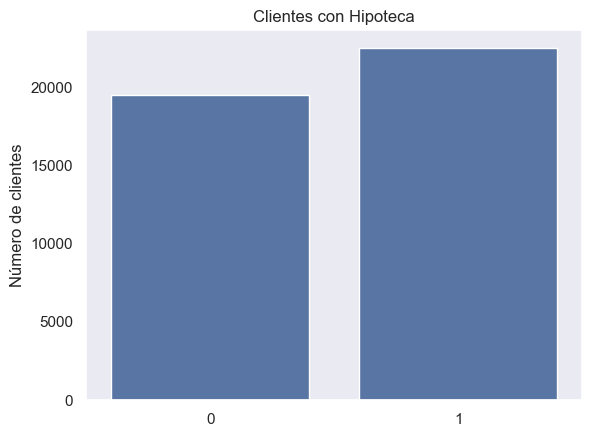

In [381]:
#Cómo este datos tiene una distribución más igualada, vamos a visualizarlo en un gráfico sencillo
sns.countplot(data=df_datos, x='hipoteca')
plt.title("Clientes con Hipoteca")
plt.xticks(rotation=0)
plt.xlabel(None)
plt.ylabel("Número de clientes")
plt.show()

In [382]:
#Nos fijamos ahora en el dato de "otros_préstamos" que también tiene un 2,4% de clientes sin datos.
tabla_ot_prest = pd.DataFrame({
    "cantidad" : df_datos["otros_prestamos"].value_counts(),
    "porcentaje" : (df_datos["otros_prestamos"].value_counts(normalize=True) * 100).round(1)
    })
tabla_ot_prest

,cantidad,porcentaje
otros_prestamos,,
0,35442,84.4
1,6532,15.6


In [383]:
# Entendamos que los clientes con  datos faltantes de morosidad, hipoteca y otros préstamos, serán valores FALSE (siendo un banco, estos datos estarían registrados) 
# Así aplicamos un método para gestión de nulos y a los clientes sin edad, les aplicamos la mediana del resto de clientes
df_datos.fillna({'moroso': 0, 'hipoteca': 0, 'otros_prestamos': 0, 'edad' : df_datos["edad"].median()}, inplace=True)

,edad,ocupacion,estado_civil,formacion,moroso,hipoteca,otros_prestamos,via_contacto,duración_llamada,campaign,pdays,previous,campaña_anterior,rotacion_laboral,IPC,ICC,euribor3m,num_empleados,acepta_campaña,fecha_contacto,latitud,longitud,ingresos,bebes,adolescentes,fecha_alta,visitas_web_mes,año
id_,,,,,,,,,,,,,,,,,,,,,,,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,38,housemaid,MARRIED,basic.4y,0,0,0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2019-08-02,41.495,-71.233,161770,1,0,2012-04-04,29,2012
e9d37224-cb6f-4942-98d7-46672963d097,57,services,MARRIED,high.school,0,0,0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2016-09-14,34.601,-83.923,85477,1,1,2012-12-30,7,2012
3f9f49b5-e410-4948-bf6e-f9244f04918b,37,services,MARRIED,high.school,0,1,0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2019-02-15,34.939,-94.847,147233,1,1,2012-02-02,5,2012
9991fafb-4447-451a-8be2-b0df6098d13e,40,admin.,MARRIED,basic.6y,0,0,0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2015-11-29,49.041,-70.308,121393,1,2,2012-12-21,29,2012
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,56,services,MARRIED,high.school,0,0,1,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2017-01-29,38.033,-104.463,63164,1,2,2012-06-20,20,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4eed05de-2a98-4227-b488-32122009b638,38,admin.,MARRIED,university.degree,0,0,0,cellular,618,2,999,0,NONEXISTENT,1.4,"93,444","-36,1",NaN,"5228,1",yes,2015-10-13,38.147,-105.582,68672,0,2,2014-03-08,22,2014
0f0aca88-4088-4fe2-905f-44fb675d9493,34,technician,MARRIED,professional.course,0,1,1,cellular,42,7,999,0,NONEXISTENT,-0.1,"93,2",-42,NaN,"5195,8",no,2018-03-17,49.235,-112.201,73578,0,2,2014-03-11,26,2014
cadadd4b-7ee5-4019-b13a-ca01bb67ca5b,38,blue-collar,SINGLE,basic.6y,0,1,0,cellular,391,2,999,0,NONEXISTENT,1.4,"93,918","-42,7",NaN,"5228,1",no,2016-09-15,40.679,-120.015,9816,2,2,2014-09-18,31,2014


In [384]:
#Volvemos a verificar los datos
(df_datos.isna().sum() / len(df_datos)*100).round(1)

edad                 0.0
ocupacion            0.8
estado_civil         0.2
formacion            4.2
moroso               0.0
hipoteca             0.0
otros_prestamos      0.0
via_contacto         0.0
duración_llamada     0.0
campaign             0.0
pdays                0.0
previous             0.0
campaña_anterior     0.0
rotacion_laboral     0.0
IPC                  1.1
ICC                  0.0
euribor3m           21.5
num_empleados        0.0
acepta_campaña       0.0
fecha_contacto       0.6
latitud              0.0
longitud             0.0
ingresos             0.0
bebes                0.0
adolescentes         0.0
fecha_alta           0.0
visitas_web_mes      0.0
año                  0.0
dtype: float64

In [385]:
#Para los registros vacíos de los campos "ocupación, estado_civil y formación", los rellenamos con el texto "SIN DATOS"
df_datos.fillna({'ocupacion': "sin datos", 'estado_civil': "sin datos", "formacion" : "sin datos"}, inplace=True)

,edad,ocupacion,estado_civil,formacion,moroso,hipoteca,otros_prestamos,via_contacto,duración_llamada,campaign,pdays,previous,campaña_anterior,rotacion_laboral,IPC,ICC,euribor3m,num_empleados,acepta_campaña,fecha_contacto,latitud,longitud,ingresos,bebes,adolescentes,fecha_alta,visitas_web_mes,año
id_,,,,,,,,,,,,,,,,,,,,,,,,,,,,
089b39d8-e4d0-461b-87d4-814d71e0e079,38,housemaid,MARRIED,basic.4y,0,0,0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2019-08-02,41.495,-71.233,161770,1,0,2012-04-04,29,2012
e9d37224-cb6f-4942-98d7-46672963d097,57,services,MARRIED,high.school,0,0,0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2016-09-14,34.601,-83.923,85477,1,1,2012-12-30,7,2012
3f9f49b5-e410-4948-bf6e-f9244f04918b,37,services,MARRIED,high.school,0,1,0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2019-02-15,34.939,-94.847,147233,1,1,2012-02-02,5,2012
9991fafb-4447-451a-8be2-b0df6098d13e,40,admin.,MARRIED,basic.6y,0,0,0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2015-11-29,49.041,-70.308,121393,1,2,2012-12-21,29,2012
eca60b76-70b6-4077-80ba-bc52e8ebb0eb,56,services,MARRIED,high.school,0,0,1,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2017-01-29,38.033,-104.463,63164,1,2,2012-06-20,20,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4eed05de-2a98-4227-b488-32122009b638,38,admin.,MARRIED,university.degree,0,0,0,cellular,618,2,999,0,NONEXISTENT,1.4,"93,444","-36,1",NaN,"5228,1",yes,2015-10-13,38.147,-105.582,68672,0,2,2014-03-08,22,2014
0f0aca88-4088-4fe2-905f-44fb675d9493,34,technician,MARRIED,professional.course,0,1,1,cellular,42,7,999,0,NONEXISTENT,-0.1,"93,2",-42,NaN,"5195,8",no,2018-03-17,49.235,-112.201,73578,0,2,2014-03-11,26,2014
cadadd4b-7ee5-4019-b13a-ca01bb67ca5b,38,blue-collar,SINGLE,basic.6y,0,1,0,cellular,391,2,999,0,NONEXISTENT,1.4,"93,918","-42,7",NaN,"5228,1",no,2016-09-15,40.679,-120.015,9816,2,2,2014-09-18,31,2014


Solo nos quedarían los campos "formación" y "euribor" con un volumen relevante de nulos, de momento no los tratamos hasta que sepamos si los vamos a utilizar o no

In [386]:
#Hacemos una visualización general de los datos
df_datos.describe(include = "all").round(0).T #trasponemos para una mejor visualización y quitamos los decimales

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
edad,43000.0,<NA>,<NA>,<NA>,40.0,17.0,33.0,38.0,46.0,98.0,10.0
ocupacion,43000,12,admin.,10873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado_civil,43000,4,MARRIED,25999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
formacion,43000,8,university.degree,12722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
moroso,43000.0,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,1.0,0.0
hipoteca,43000.0,<NA>,<NA>,<NA>,1.0,0.0,0.0,1.0,1.0,1.0,0.0
otros_prestamos,43000.0,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,1.0,0.0
via_contacto,43000,2,cellular,27396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duración_llamada,43000.0,NaN,NaN,NaN,258.0,0.0,102.0,179.0,319.0,4918.0,259.0
campaign,43000.0,NaN,NaN,NaN,3.0,1.0,1.0,2.0,3.0,56.0,3.0


En esta visión general, inicialmente vemos algunos datos relevantes:  
-La media de edad de los clientes es de 40 años, aunque tenemos algún cliente fuera de rango 17 y 98 años, posiblemente outliers  
-Tenemos 11 tipos de ocupaciones, 3 estados civiles, 7 categorías de formación.  
-Se utilizaron 2 vías de contacto, la principal fue a través de móvil  
-En la campaña anterior hay más de 37k clientes con la etiqueta "NONEXISTENT" entendemos que no participaron en la campaña anterior  
-En los ingresos vemos que hay mucha desviación, la media es de 93.241€, pero oscilan entre 5,8k y 180,8k, una desviación estándar de 50,5K  
 

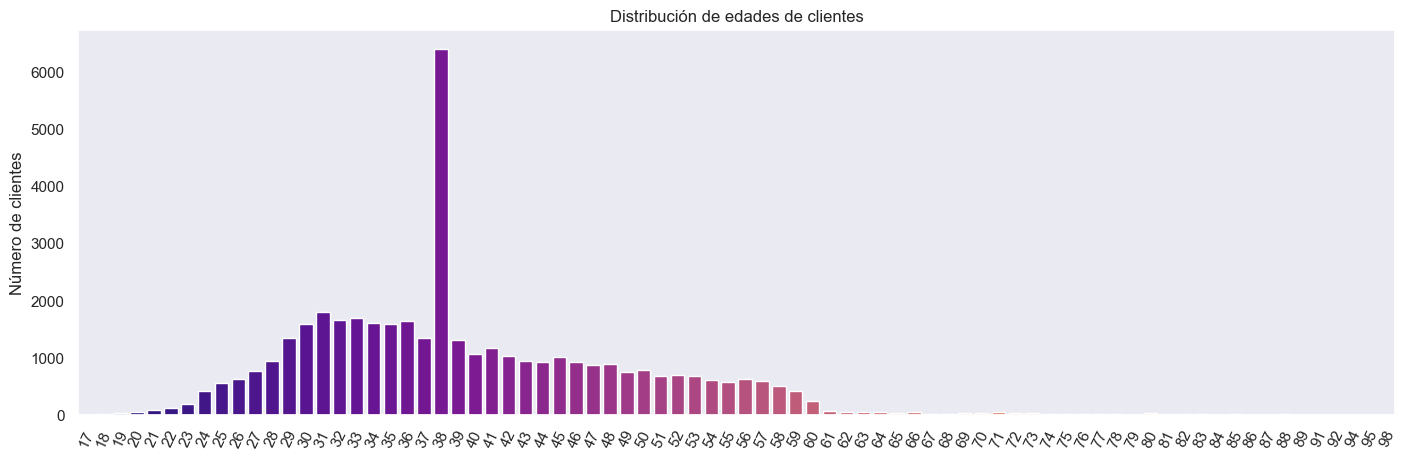

In [421]:
# Veamos como se distribuyen las edades
plt.figure(figsize=(17, 5)) 
sns.countplot( #Definimos el origen de los datos, la columna que vamos a utilizar y el orden, la paleta de colores, no queremos leyenda
    data = df_datos, 
    x = "edad", 
    hue = "edad", 
    palette = "plasma",
    legend = None) 
plt.title("Distribución de edades de clientes") #Ponemos título al gráfico
plt.ylabel("Número de clientes") # Eliminamos el título del Y por redundante
plt.xlabel(None) # Eliminamos el título del Y por redundante
plt.xticks(rotation=65)
plt.show()

Como en un paso anterior, aplicamos la mediana de edad a los valores nulos, ahora tenemos un pico ilógico en ese dato, 38 años, así que graficaremos de nuevo excluyendo a los clientes de 38 años

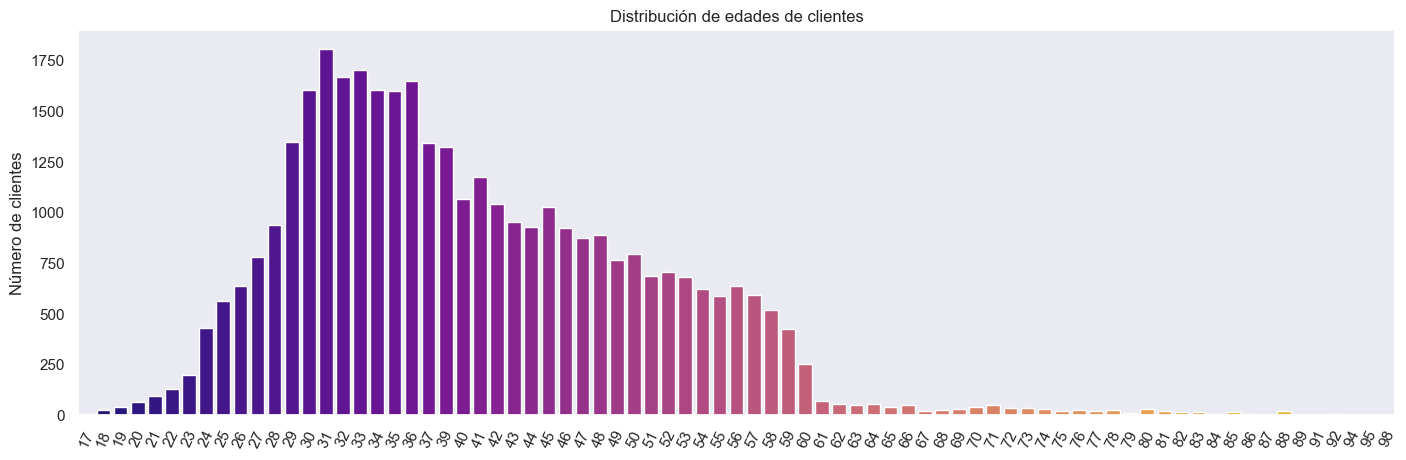

In [388]:
# Veamos como se distribuyen las edades, eliminando a los de 38 años.
plt.figure(figsize=(17, 5)) 
sns.countplot( #Definimos el origen de los datos, la columna que vamos a utilizar y el orden, la paleta de colores, no queremos leyenda
    data = df_datos[df_datos["edad"] != 38], #Aquí definimos el dataset con los clientes que cumplan la condición de NO tener 38 años 
    x = "edad", 
    hue = "edad", 
    palette = "plasma",
    legend = None) 
plt.title("Distribución de edades de clientes") #Ponemos título al gráfico
plt.ylabel("Número de clientes") 
plt.xlabel(None) # Eliminamos el título del Y por redundante
plt.xticks(rotation=65) # Rotamos las etiquetas del eje X
plt.show()

Ahora lo vemos más claro, el nucleo de nuestros clientes está entre 29 y 39 años. Hasta 23 años el volumen es muy bajo al igual que a partir de los 61, que disminuye drásticamente

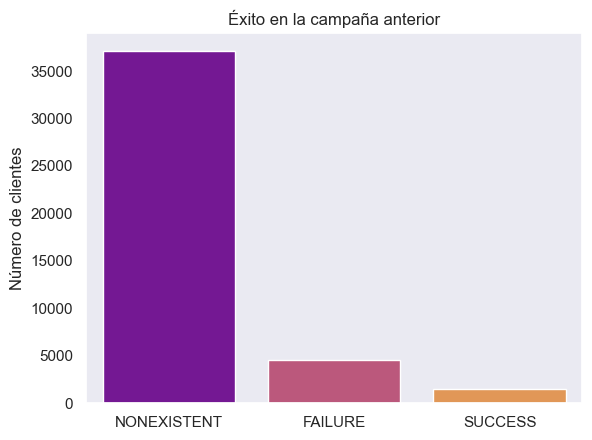

In [425]:
# Visualizamos los datos del resultado de la campaña anterior en un gráfico
sns.countplot( #Definimos el origen de los datos, la columna que vamos a utilizar y el orden, la paleta de colores, no queremos leyenda
    data = df_datos, 
    x = "campaña_anterior", 
    order =  df_datos["campaña_anterior"].value_counts().index,
    hue = "campaña_anterior", 
    palette = "plasma",
    legend = None) 
plt.title("Éxito en la campaña anterior") #Ponemos título al gráfico
plt.ylabel("Número de clientes") # Eliminamos el título del Y por redundante
plt.xlabel(None) # Eliminamos el título del Y por redundante
plt.show()

Vemos que la mayoría de clientes no participaron en la campaña anterior, y de los que si lo hicieron, en pocos hubo éxito, vamos a verlo en valores absolutos y en porcentaje

In [390]:
tabla_camp_ant = pd.DataFrame({
    "cantidad" : df_datos["campaña_anterior"].value_counts(),
    "porcentaje" : (df_datos["campaña_anterior"].value_counts(normalize=True) * 100).round(1)
})

tabla_camp_ant

,cantidad,porcentaje
campaña_anterior,,
NONEXISTENT,37103,86.3
FAILURE,4461,10.4
SUCCESS,1436,3.3


Veamos ahora los datos que contienen algunas de las columnas que podemos usar para categorizar los datos

In [391]:
# Empezamos por la ocupación que tiene cada cliente
tabla_ocup = pd.DataFrame({
    "cantidad" : df_datos["ocupacion"].value_counts(),
    "porcentaje" : (df_datos["ocupacion"].value_counts(normalize=True) *100).round(1)
})
tabla_ocup

,cantidad,porcentaje
ocupacion,,
admin.,10873,25.3
blue-collar,9654,22.5
technician,7026,16.3
services,4162,9.7
management,3050,7.1
retired,1790,4.2
entrepreneur,1522,3.5
self-employed,1489,3.5
housemaid,1123,2.6


In [392]:
#Vamos a traducirlos a castellano
mapeo_ocupaciones = {
    "admin.": "Administrativo",
    "blue-collar": "Obrero",
    "technician": "Técnico",
    "services": "Servicios",
    "management": "Directivo",
    "retired": "Jubilado",
    "entrepreneur": "Emprendedor",
    "self-employed": "Autónomo",
    "housemaid": "Empleada del hogar",
    "unemployed": "Desempleado",
    "student": "Estudiante"
}

In [393]:
df_datos["ocupacion_es"] = df_datos["ocupacion"].map(mapeo_ocupaciones)

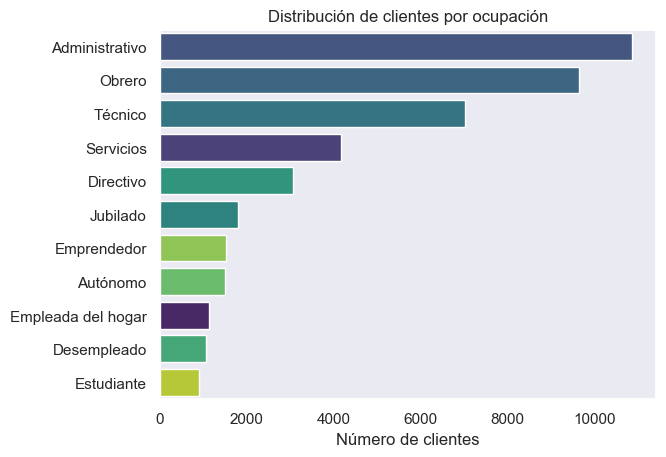

In [431]:
# Visualizamos los datos en un gráfico
sns.countplot( #Definimos el origen de los datos, la columna que vamos a utilizar y el orden, la paleta de colores, no queremos leyenda
    data = df_datos, 
    y = "ocupacion_es", 
    order =  df_datos["ocupacion_es"].value_counts().index,
    hue = "ocupacion_es", 
    palette = "viridis", # tenemos estas alternativas de paletas: "magma" "plasma" "coolwarm" "Set2" "Pastel1"....
    legend = None) 
plt.title("Distribución de clientes por ocupación") #Ponemos título al gráfico
plt.xlabel("Número de clientes") # Ponemos título al eje X
plt.ylabel(None) # Eliminamos el título del Y por redundante
plt.show()

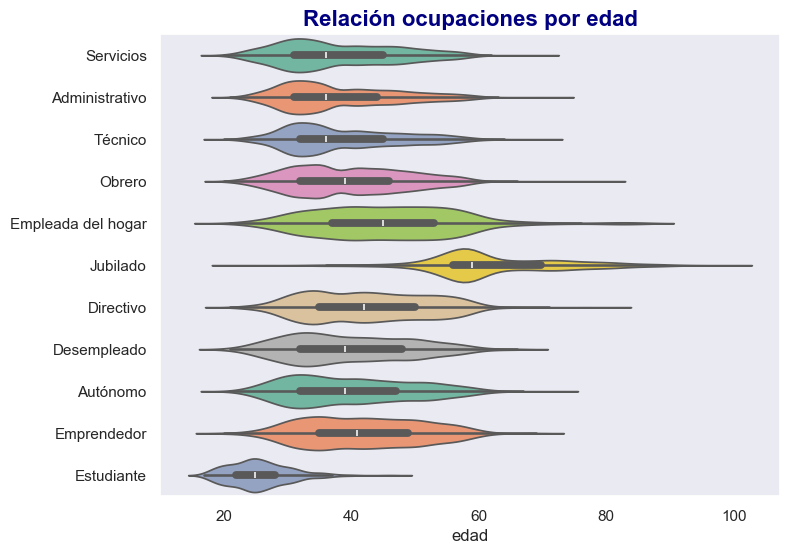

In [426]:
# Veamos en un gráfico como se ralacionan las ocupaciones con las edades
plt.figure(figsize=(8, 6)) 
sns.violinplot(
    data=df_datos[df_datos["edad"] != 38], #Volvemos a excluir a los de 38 años
    x="edad",
    y="ocupacion_es",
    hue = "ocupacion_es",
    palette = "Set2",
    legend = False
)
plt.title(
    "Relación ocupaciones por edad", 
    fontsize=16, 
    fontweight="bold", 
    color="navy"
)
plt.ylabel(None)
plt.show()


La mayoría de las opcupaciones tienen una distribución parecida, excepto, como es lógico, la de Estudiante que tiene una media de edad más baja, y la de jubilados, que se concentran más alrededor de los 60 años. Del resto, observando con más detalle, vemos que las Empleadas del hogar cubren una franja más amplia de edades y que los Directivos y Emprendedores, tienen una media de edad algo superior al resto.

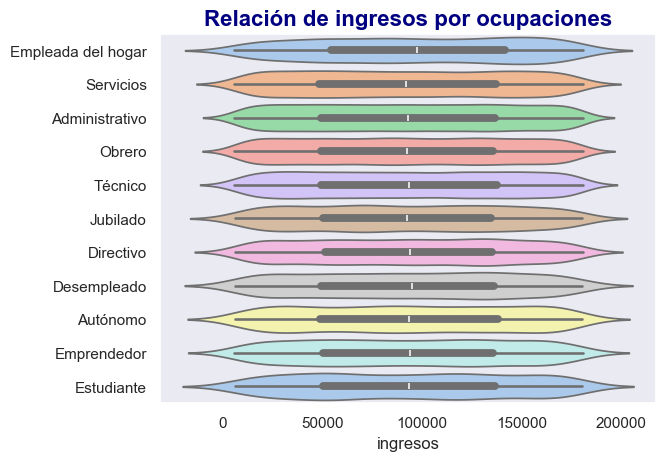

In [396]:
# Siguiendo con las profesiones, veamos cuales son las mejor pagadas
sns.violinplot(
    data=df_datos[df_datos["ingresos"] != 0], #excluimos los que no tienen ingresos
    x="ingresos",
    y="ocupacion_es",
    hue = "ocupacion_es",
    palette = "pastel",
    legend = False
)
plt.title(
    "Relación de ingresos por ocupaciones", 
    fontsize=16, 
    fontweight="bold", 
    color="navy"
)
plt.ylabel(None)
plt.show()


Este resultado no tiene mucho sentido, son demasiado parecidos todos los segmentos, probablemente los datos fueron creados de forma aleatoria, sin seguir un patrón de profesiones
Veamos los datos de ingresos medios por profesión

In [397]:
# Veamos la media de ingresos por profesión
tabla_ocup_ingresos = df_datos.groupby("ocupacion_es").agg( # Creamos una tabla en la que agrupamos "groupby" por ocupación
    número_clientes = ("ocupacion_es", "count"), #calculamos el numero de clientes por profesión
    media_ingresos = ("ingresos", "mean") #y la media de ingresos de cada una
)
tabla_ocup_ingresos["media_ingresos"] = tabla_ocup_ingresos["media_ingresos"].round(2)
tabla_ocup_ingresos


,número_clientes,media_ingresos
ocupacion_es,,
Administrativo,10873,93285.09
Autónomo,1489,93804.71
Desempleado,1063,93490.26
Directivo,3050,93512.84
Empleada del hogar,1123,97263.78
Emprendedor,1522,93581.47
Estudiante,903,93547.69
Jubilado,1790,92683.89
Obrero,9654,92633.34


No parece muy lógico que los ingresos medios de los estudiantes sean similares a los de los directivos o autónomos... De hecho, la media más alta la tienen las empleadas del hogar. Descartamos el uso de este dato por el momento.

In [398]:
# Vamos a ver como se distribuyen los clientes por Estado Civil
tabla_est_civ = pd.DataFrame({
    "cantidad": df_datos["estado_civil"].value_counts(),
    "porcentaje": (df_datos["estado_civil"].value_counts(normalize=True) * 100).round(2)
})

tabla_est_civ

,cantidad,porcentaje
estado_civil,,
MARRIED,25999,60.46
SINGLE,12105,28.15
DIVORCED,4811,11.19
sin datos,85,0.20


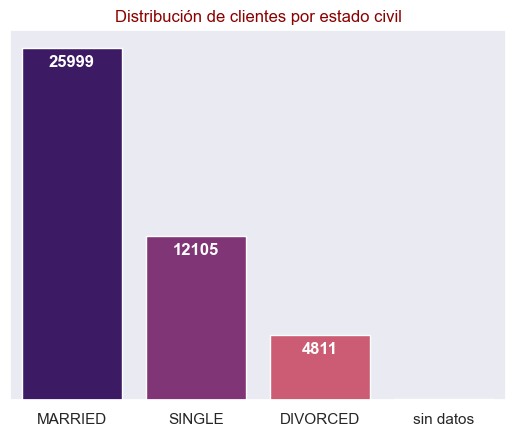

In [399]:
graf_est_civ = sns.countplot( #Esta vez, guardamos el gráfico en una variable
    data = df_datos, 
    x = "estado_civil",
    hue = "estado_civil",
    palette = "magma",
    legend = None
    ) 
for p in graf_est_civ.patches: #Añadimos etiquetas de datos a las barras
    altura = p.get_height() #definimos la altura de cada una
    graf_est_civ.annotate(
        f"{int(altura)}", #el tyexto de la etiqueta será precisamente la altura de cada barra
        (p.get_x() + p.get_width() / 2, altura - 500), # bajamos la altura de la etiqueta para que no quede al borde
        ha='center', #centramos la etiqueta horizontalmente
        va= "top",
        fontsize=12, #definimos el tamaño de la fuente
        fontweight="bold", #las ponemos en negrita
        color = "white" #y en blanco para que destaque
    )
plt.title("Distribución de clientes por estado civil", color = "darkred") #Esta vez cambiamos el color del título
graf_est_civ.yaxis.set_visible(False) # Deshabilitamos el eje Y ya que tenemos los datos en las etiquetas
plt.xlabel(None)
plt.show()

La mayoría de nuestros clientes están casados, seguidos de solteros y un menor porcentaje de divorciados. Siguiendo por esta línea, veamos cuantos tienen hijos

In [400]:
df_datos["num_hijos"] = df_datos["bebes"] + df_datos["adolescentes"] # De momento sumamos el número de hijos bebés y adolescentes
df_datos["tiene_hijos"] = df_datos["num_hijos"] > 0 # Ahora categorizamos los clientes CON/SIN hijos
df_datos["tiene_hijos"] = df_datos["tiene_hijos"].astype("int64") #lo convertimos de booleano a número para ver mejor las estadísticas
df_datos["tiene_hijos"].dtype

dtype('int64')

In [401]:
tabla_hijos = pd.DataFrame({ #Vamos a ver como se distribuyen los clientes según si tienen hijos o no
    "cantidad" : df_datos["tiene_hijos"].value_counts(),
    "porcentaje" : (df_datos["tiene_hijos"].value_counts(normalize = True) * 100).round(1)
})
tabla_hijos

,cantidad,porcentaje
tiene_hijos,,
1,38246,88.9
0,4754,11.1


Vemos que la mayoría SI tienen hijos, vamos a ver ahora la relación entre la condición de tener hijos y el estado civil

In [402]:
tabla_est_hijos = pd.crosstab( #creamos primero una tabla resumen con los datos que nos interesan
    df_datos["estado_civil"],
    df_datos["tiene_hijos"], 
   ) 
tabla_est_hijos

tiene_hijos,0,1
estado_civil,,
DIVORCED,521,4290
MARRIED,2856,23143
SINGLE,1363,10742
sin datos,14,71


Choca el alto número de solteros con hijos, vamos a ver la misma tabla en porcentajes.

In [403]:
tabla_est_hijos_porc = (pd.crosstab(
    df_datos["estado_civil"],
    df_datos["tiene_hijos"], 
    normalize ="index"
) *100).round(1)
tabla_est_hijos_porc

tiene_hijos,0,1
estado_civil,,
DIVORCED,10.8,89.2
MARRIED,11.0,89.0
SINGLE,11.3,88.7
sin datos,16.5,83.5


Efectivamente, no solo el porcentaje de solteros con hijos es anormalmente alto, sino que además la proporción de clientes con y sin hijos de las tres categorías es prácticamente igual, lo que es poco probable estadisticamente. Al igual que los ingresos, parece que este dato también es artificial y no podremos obtener respuestas

In [404]:
#Veamos cuales fueron las vías de contacto que se utilizaron
tabla_via_cont = pd.DataFrame({
    "cantidad" : df_datos["via_contacto"].value_counts(),
    "porcentaje" : (df_datos["via_contacto"].value_counts(normalize=True) * 100).round(1)
})
tabla_via_cont

,cantidad,porcentaje
via_contacto,,
cellular,27396,63.7
telephone,15604,36.3


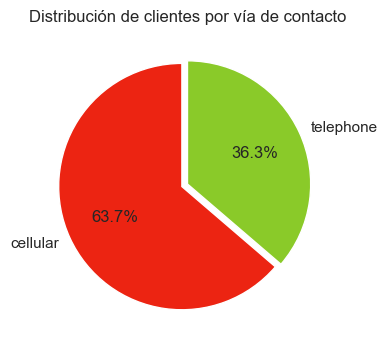

In [440]:
#Visualizamos ahora este dato en un gráfico de sectores
colores = ["#ec2412", "#8aca29"] #definimos colores que vamos a utilizar
df_datos["via_contacto"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%", #Generamos etiquetas de datos con un decimal
    startangle=90,
    figsize=(4,4), #definimos el tamaño del gráfico
    colors = colores,
    explode=[0.05, 0] #separamos un poco los sectores
)
plt.title("Distribución de clientes por vía de contacto")
plt.show()


Casi dos tercios de las llamadas fueron a teléfonos móviles, veamos que relación hay entre las vías de contacto y la duración de las llamadas

In [406]:
# Vamos a ver como fueron los contactos con los clientes
tabla_duracion_telf = df_datos.groupby("via_contacto").agg( # Creamos una tabla en la que agrupamos "groupby" por vía de contacto
    número_llamadas = ("via_contacto", "count"), #contamos cuantas llamas se hicieron por cada vía
    duración_media = ("duración_llamada", "mean") #y la media de duración de las llamadas de cada una
)
tabla_duracion_telf["duración_media"] = tabla_duracion_telf["duración_media"].round(2)
tabla_duracion_telf

,número_llamadas,duración_media
via_contacto,,
cellular,27396,262.85
telephone,15604,248.76


No hay mucha diferencia entre la duración media de uno y otro tipo de llamadas. No nos aporta mucho esta información. Exploremos los resultados de la campaña

In [407]:
tabla_resultado_camapaña = pd.DataFrame({
    "respuesta" : df_datos["acepta_campaña"].value_counts(),
    "porcentaje" : (df_datos["acepta_campaña"].value_counts(normalize = True) * 100).round(1)
})
tabla_resultado_camapaña

,respuesta,porcentaje
acepta_campaña,,
no,38156,88.7
yes,4844,11.3


De los 43.000 clientes, el 11.3% aceptaron la campaña. Vamos a ver ahora cual es el perfil de los clientes que SI aceptaron la campaña

In [408]:
#Geneamos un DataFrame que contengo unicamente los registros de los cientes que aceptaron la campaña
df_clientes_OK = df_datos[df_datos["acepta_campaña"] == "yes"].copy()
df_clientes_OK = df_clientes_OK.drop(columns=["IPC", "ICC","euribor3m", "latitud", "longitud"])#eliminamos algunas columnas que no vamos a usar
df_clientes_OK["tiene_prestamo"] = ((df_clientes_OK["hipoteca"] == 1) | (df_clientes_OK["otros_prestamos"] == 1)).astype("Int64")


In [409]:
#hagamos un resumen de los datos estadíscos de este grupo de clientes con un "describe()"
df_clientes_OK.describe().round(1).T

,count,mean,min,25%,50%,75%,max,std
edad,4844.0,40.5,17.0,31.0,38.0,47.0,98.0,13.0
moroso,4844.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hipoteca,4844.0,0.5,0.0,0.0,1.0,1.0,1.0,0.5
otros_prestamos,4844.0,0.1,0.0,0.0,0.0,0.0,1.0,0.4
duración_llamada,4844.0,551.6,63.0,253.0,449.0,740.0,4199.0,398.4
campaign,4844.0,2.1,1.0,1.0,2.0,2.0,23.0,1.7
pdays,4844.0,790.5,0.0,999.0,999.0,999.0,999.0,404.5
previous,4844.0,0.5,0.0,0.0,0.0,1.0,6.0,0.9
rotacion_laboral,4844.0,-1.2,-3.4,-1.8,-1.8,-0.1,1.4,1.6
fecha_contacto,4811,2017-07-07 01:00:27.686551,2015-01-01 00:00:00,2016-04-15 12:00:00,2017-07-07 00:00:00,2018-10-04 12:00:00,2019-12-31 00:00:00,NaN


Una vez localizados los 4.844 clientes que SI aceptaron la campaña, podemos sacar algunas conclusiones de este segmento de clientes:
- Tienen una edad media de 40.5 años, aunque se mantienen los outliers de 17 y 98 años
- Más de la mitad tienen hipoteca o algún otro préstamo
- El tiempo invertido en las llamadas de captación es notablemente mayor en este segmento que en el global que vimos anteriormente
- Se hicieron de media 2 llamadas a cada uno de estos clientes, hubo caso excepcional al que se le hicieron 23 llamadas! La mayoría no habían sido contactados en la campaña anterior
- En lo económico, el ingreso medio por cliente es de 92.584€, el rango va desde 5k hasta +180K (aunque ya vimos que este dato no era muy fiable)



*Reutilizamos ahora algunos de los códigos anteriores para estudiar los datos de estos clientes que SI aceptaron la campaña*

In [410]:
tabla_est_hijos_porc_ok = (pd.crosstab(
    df_clientes_OK["estado_civil"],
    df_clientes_OK["tiene_hijos"], 
    normalize ="index"
) *100).round(1)
tabla_est_hijos_porc_ok

tiene_hijos,0,1
estado_civil,,
DIVORCED,10.4,89.6
MARRIED,11.9,88.1
SINGLE,11.3,88.7
sin datos,7.7,92.3


Al igual que en la tabla global, este dato parece artificial, no nos aporta conclusiones válidas

In [411]:
tabla_hip_ok = pd.DataFrame({
    "cantidad" : df_clientes_OK["hipoteca"].value_counts(),
    "porcentaje" : (df_clientes_OK["hipoteca"].value_counts(normalize=True) * 100).round(1)
    })
tabla_hip_ok

,cantidad,porcentaje
hipoteca,,
1,2616,54.0
0,2228,46.0


La distribución de clientes con y hipoteca está bastante equilibrado, no parece que sea un dato determinante a la hora de aceptar la campaña

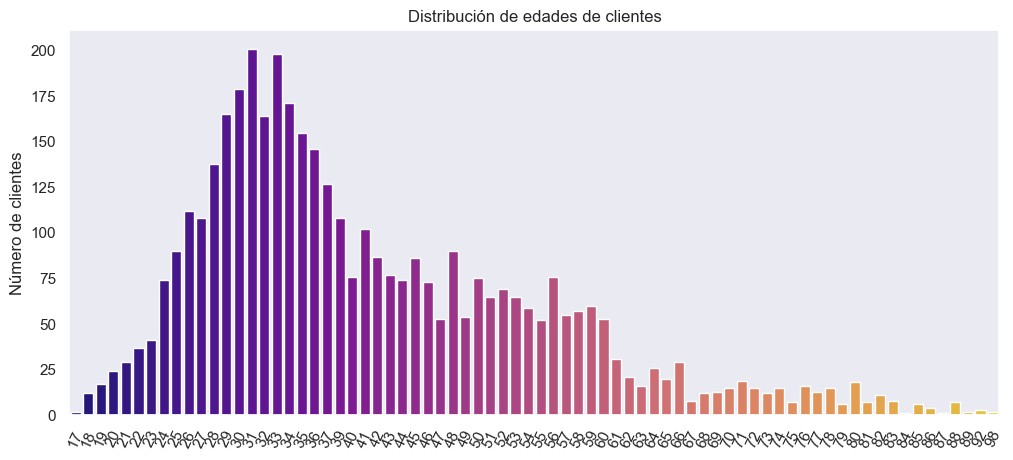

In [412]:
# Veamos como se distribuyen las edades, eliminando a los de 38 años.
plt.figure(figsize=(12, 5)) 
sns.countplot( #Definimos el origen de los datos, la columna que vamos a utilizar y el orden, la paleta de colores, no queremos leyenda
    data = df_clientes_OK[df_clientes_OK["edad"] != 38], #Aquí definimos el dataset con los clientes que cumplan la condición de NO tener 38 años 
    x = "edad", 
    hue = "edad", 
    palette = "plasma",
    legend = None) 
plt.title("Distribución de edades de clientes") #Ponemos título al gráfico
plt.ylabel("Número de clientes") 
plt.xlabel(None) # Eliminamos el título del Y por redundante
plt.xticks(rotation=65) # Rotamos las etiquetas del eje X
plt.show()

In [413]:
df_datos_sin_38 = df_datos[df_datos["edad"] != 38]
mediana_edad_datos = df_datos_sin_38["edad"].median()

df_OK_sin_38 = df_clientes_OK[df_clientes_OK["edad"] != 38]
mediana_edad_OK = df_OK_sin_38["edad"].median()

tabla_edades= pd.DataFrame({    
    "mediana_Global" : [mediana_edad_datos],    
    "mediana_OK" : [mediana_edad_OK]
    })
tabla_edades


,mediana_Global,mediana_OK
0,39.0,37.0


Aqui vemos una pequeña diferencia, la mediana de la edad de los clientes que aceptaron la campaña es más baja que la global, a pesar de la cola se alarga bastante por la derecha, es decir, que hay bastante clientes mayores, pero visualmente, vemos en el gráfico que el bloque mayoritario está entre los 28 y los 36 años

In [414]:
# Veamos a que se dedican estos clientes que aceptaron la campaña
tabla_ocup_ok = pd.DataFrame({
    "cantidad" : df_clientes_OK["ocupacion_es"].value_counts(),
    "porcentaje" : (df_clientes_OK["ocupacion_es"].value_counts(normalize=True) *100).round(1)
})
tabla_ocup_ok

,cantidad,porcentaje
ocupacion_es,,
Administrativo,1415,29.4
Técnico,762,15.9
Obrero,665,13.8
Jubilado,451,9.4
Directivo,342,7.1
Servicios,336,7.0
Estudiante,283,5.9
Autónomo,161,3.4
Desempleado,153,3.2


Casi el 60% de los clientes que aceptaron la campaña se concentran las categorías de Administrativos, Técnicos y Obreros

In [415]:
# Vamos ver como afecta la formación de los clientes
tabla_form_ok = pd.DataFrame({
    "cantidad" : df_clientes_OK["formacion"].value_counts(),
    "porcentaje" : (df_clientes_OK["formacion"].value_counts(normalize=True) *100).round(1)
})
tabla_form_ok

,cantidad,porcentaje
formacion,,
university.degree,1748,36.1
high.school,1076,22.2
professional.course,620,12.8
basic.9y,493,10.2
basic.4y,448,9.2
sin datos,261,5.4
basic.6y,194,4.0
illiterate,4,0.1


También aquí vemos una clara diferencia, la mayoría de los clientes que dieron el OK tienen formación superior. Veamos como se relacionan los oficios con la formación.

In [416]:
tabla_form_ocup_ok = (pd.crosstab(
    df_clientes_OK["formacion"],
    df_clientes_OK["ocupacion_es"], 
    normalize ="index"
) *100).round(1)
tabla_form_ocup_ok

ocupacion_es,Administrativo,Autónomo,Desempleado,Directivo,Empleada del hogar,Emprendedor,Estudiante,Jubilado,Obrero,Servicios,Técnico
formacion,,,,,,,,,,,
basic.4y,2.3,0.5,3.8,1.1,12.4,1.6,1.8,43.8,29.1,1.6,2.0
basic.6y,4.1,0.5,2.1,5.7,2.6,4.7,3.6,5.2,57.5,10.9,3.1
basic.9y,9.1,3.9,5.3,2.2,0.6,2.4,7.3,4.3,50.8,6.3,7.7
high.school,37.4,0.7,3.4,1.5,1.2,1.6,10.9,6.0,9.2,19.4,8.7
illiterate,0.0,25.0,0.0,0.0,0.0,25.0,0.0,50.0,0.0,0.0,0.0
professional.course,8.1,3.6,3.6,1.3,1.8,1.6,2.7,9.5,6.8,3.4,57.7
sin datos,16.5,1.2,2.1,8.2,2.5,1.6,25.5,13.6,9.9,8.2,10.7
university.degree,49.5,6.0,2.4,15.6,1.0,3.8,2.1,3.9,0.6,1.6,13.4


Esta tabla es interesante, pero tiene muchos datos y dificulta la lectura, así que vamos a hacer un mapa de calor para facilitar su lectura

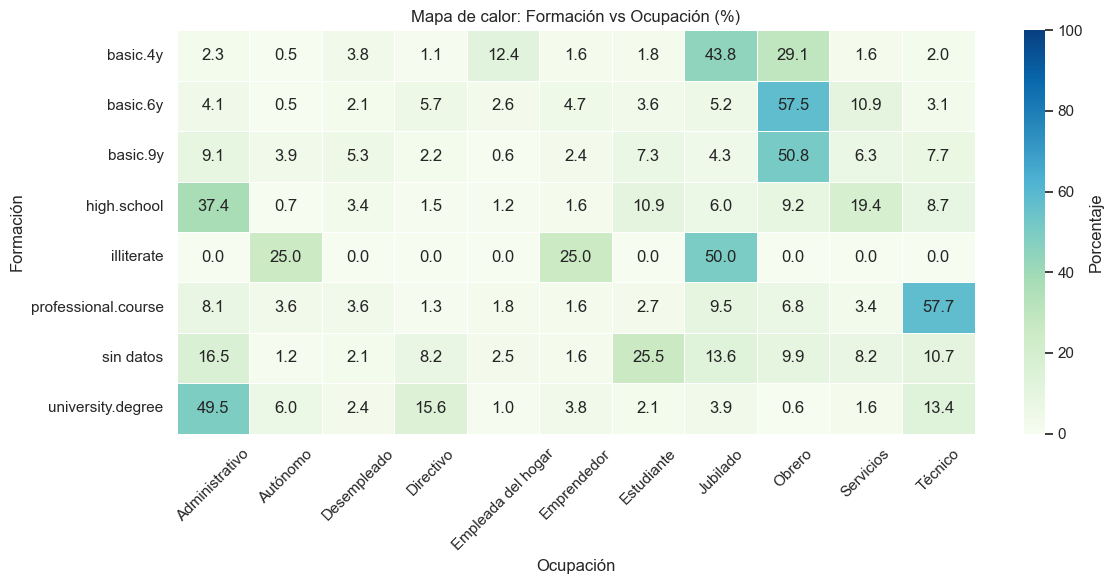

In [423]:
plt.figure(figsize=(12, 6))  # ajustamos el tamaño a A4 en horizontal
mapa_calor = sns.heatmap(
    tabla_form_ocup_ok,
    cmap="GnBu",        # definimos los colores de los valores
    annot=True,           # hacemos que se muestren los valores
    fmt=".1f",            # ponemos formato decimal, sin el "%" para no saturar
    linewidths=.5,        # líneas entre celdas
    cbar_kws={"label": "Porcentaje"},  # etiqueta de la barra de color
    vmin=0, vmax=100      # opcional: fija escala 0-100 si trabajas con %
)
#Ponemos títulos a los ejes y al propio gráfico
mapa_calor.set_xlabel("Ocupación")
mapa_calor.set_ylabel("Formación")
plt.title("Mapa de calor: Formación vs Ocupación (%)")
plt.xticks(rotation=45)
plt.tight_layout()

# Guardamos la imagen por si necesitamos utilizarla en otro documento
plt.savefig("mapa_calor_formacion_ocupacion.png", dpi=300)
plt.show()


Con este gráfico vemos algunos datos interesantes, como que la mitad de Universitarios trabajan como administrativos, que la mayoría de los clientes con Formación Profesional trabajan como técnicos, que la formación de los obreros es mucho más baja que el resto o que hay un Autónomo y un Emprendedor que son analfabetos! Tambien vemos que los cleintes que solo tienen formación básica (en sus tres categorías) trabajan como obreros o están jubilados

In [418]:
# Vamos a ver como se distribuyen los clientes por Estado Civil
tabla_est_civ_ok = pd.DataFrame({
    "cantidad": df_clientes_OK["estado_civil"].value_counts(),
    "porcentaje": (df_clientes_OK["estado_civil"].value_counts(normalize=True) * 100).round(2)
})

tabla_est_civ_ok

,cantidad,porcentaje
estado_civil,,
MARRIED,2655,54.81
SINGLE,1686,34.81
DIVORCED,490,10.12
sin datos,13,0.27


Más de la mitad están casados

Por último, una vez terminada la exploración de los datos, guardamos en un CSV el resumen de los datos de los clientes que NO tienen 38 años y que SI aceptaron la campaña

In [419]:
filtro_38 = df_datos["edad"] !=38
filtro_OK = df_datos["acepta_campaña"] == "yes"

df_filtrado = df_datos[filtro_38 & filtro_OK].copy()
df_filtrado.to_csv("clientes_OK.csv", index=False)